# Station graph
***

In this notebook I will explore how to create a graph of the station topology. I will find for each station in CAMELS-ES its inmediate downstream station, and then I will create a network (graph) of each river basin.

In [ ]:
import pyflwdir
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from pathlib import Path
from tqdm.auto import tqdm

In [ ]:
def find_downstream_neighbor(idx: int, flwdir: pyflwdir.FlwdirRaster, lookup_dict: dict) -> int:
    """
    Finds the station inmediately downstream of the input point.

    Parameters:
    -----------
    idx: int
        Identifier of the input pixel in the flow direction raster (`flwdir`)
    flwdir: pyflwdir.FlwdirRaster
        Flow direction raster
    lookup_dict: dictionary
        Keys are pixel IDs in `flwdir` and values the station IDs

    Returns:
    --------
    int: the ID of the station inmediately downstream
    """

    # draw the flowpath
    paths, dists = flwdir.path(idx, unit='m')
    path, dist = paths[0], dists[0]

    # find station in that flowpath
    for pixel in path[0][1:]:
        if pixel in lookup_dict:
            ID = lookup_dict[pixel]
            return (ID, dist_to_outlet[0])
    
    return (pd.NA, dist_to_outlet[0])

In [2]:
# configure paths
path_merit = Path('/home/casadoj/Data/MERIT/ES')
path_camels = Path('/home/casadoj/Data/CAMELS-ES')

In [3]:
# load flow direction map and convert it to `flwdir`
flwdir = rxr.open_rasterio(path_merit / 'dir.tif').squeeze(dim='band')
crs = flwdir.rio.crs
flwdir = pyflwdir.from_array(
    flwdir.data,
    ftype='d8',
    transform=flwdir.rio.transform(),
    check_ftype=False,
    latlon=True
)

In [262]:
# Compute upstream area map in km²
upstream_area = flwdir.upstream_area(unit='km2')

In [ ]:
# load stations geolocated in the MERIT DEM
stations = gpd.read_file(
    path_camels / 'preprocessing' / 'lfcoords' / 'old' / 'stations_camelses_3sec.shp',
    columns=['ID', 'geometry', 'area_3sec']
).set_index('ID')
stations.rename(columns={'area_3sec': 'area_skm'}, inplace=True)
stations['type'] = 'station'
if stations.crs != crs:
    points.to_crs(crs)


# get station indices in the flow direction object
stations['flwdir_index'] = flwdir.index(
    xs=stations.geometry.x,
    ys=stations.geometry.y
)

In [245]:
stations.head()

,area_skm,geometry,type,flwdir_index
ID,,,,
1080,781.0,POINT (-2.02667 43.2275),station,38277568
1103,458.0,POINT (-2.40083 43.22917),station,38241119
1105,216.0,POINT (-1.94167 43.24333),station,37935670
1106,674.0,POINT (-1.73 43.295),station,36819924
1107,36.0,POINT (-1.87583 43.29833),station,36747749


## `flwdir`


### Outlet

In [273]:
# compute all flowpaths
paths, dists = flwdir.path(stations.flwdir_index, unit='m')

# find river outlets
outlets_idx = list(set(path[-1] for path in paths))
print(f'no. outlets: {len(outlets_idx)}')

# create GeoDataFrame of outlets
outlets = gpd.GeoDataFrame(
    data={'flwdir_index': outlets_idx, 'type': 'outlet', 'area': pd.NA},
    geometry=gpd.points_from_xy(*flwdir.xy(outlets_idx)),
    crs=crs
)
outlets.index.name = 'ID'
outlets['area_skm'] = upstream_area.ravel()[outlets.flwdir_index].round(0)

no. outlets: 61


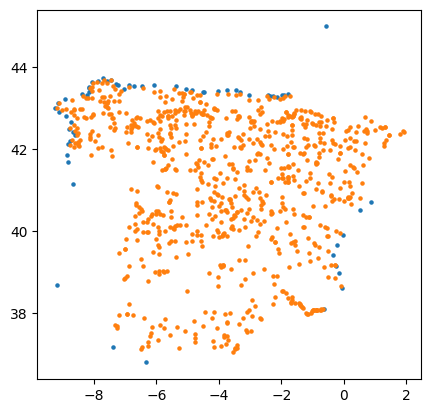

In [249]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

outlets.plot(ax=ax, markersize=5)
stations.plot(ax=ax, markersize=5);

### Downstream point

In [274]:
# merge stations and outlets
points = pd.concat([stations, outlets], axis=0)

In [275]:
# find points downstream
pixel_to_id = dict(zip(points.flwdir_index, points.index))
points[['downstream_ID', 'dist_to_outlet']] = [find_downstream_neighbor(idx, flwdir, pixel_to_id) for idx in points.flwdir_index]

In [276]:
# compute distance to downstream station
dist_m = pd.Series(index=points.index, name='dist_m')
for ID in tqdm(dist_m.index):
    ds_ID = points.loc[ID, 'downstream_ID']
    if pd.isnull(ds_ID):
        dist_m[ID] = points.loc[ID, 'dist_to_outlet']
    else:
        dist_m[ID] = np.diff(points.loc[[ds_ID, ID], 'dist_to_outlet'])[0]
points['dist_m'] = dist_m

  0%|          | 0/898 [00:00<?, ?it/s]

## Graph

In [144]:
import networkx as nx

In [277]:
# Initialize a Directed Graph
G = nx.DiGraph()

# Add all stations as nodes
G.add_nodes_from(points.index, type=points.type, area=points.area_skm)

# Add edges only for stations that are not outlet
edges = points.dropna(subset=['downstream_ID'])
for ID, row in edges.iterrows():
    G.add_edge(u_of_edge=ID, v_of_edge=row['downstream_ID'], dist_m=row['dist_m'])

print(f"Graph created with {G.number_of_nodes()} stations and {G.number_of_edges()} connections.")

Graph created with 898 stations and 837 connections.


In [280]:
target_node = 1295

upstream_stations = list(nx.ancestors(G, target_node))
print('ancestors:', upstream_stations)
source_node = upstream_stations[-1]

if G.has_node(source_node) and G.has_node(target_node):
    if nx.has_path(G, source_node, target_node):
        dist = nx.shortest_path_length(G, source_node, target_node, weight='dist_m')
        print(f"Distance {source_node}-{target_node}: {dist/1000:.2f} km")
    else:
        print("Nodes exist, but they are in different river basins!")
else:
    print("One of the station IDs is missing from the graph.")

ancestors: [1296, 1293]
Distance 1293-1295: 9.27 km


In [279]:
outlets = [node for node, degree in G.out_degree() if degree == 0]
print(f'{len(outlets)} outlet stations.')

headwaters = [node for node, degree in G.in_degree() if degree == 0]
print(f'{len(headwaters)} headwater stations.')

61 outlet stations.
414 headwater stations.
